# HDC Hamming-Distance Precision Sweep

(16-bit machine) 16-bit blocks with 12-bit saturating counter (max hamming distance of 12)
e.g., Hamming distance of 14 is indistinguishable from 12. The total *detected* distance is the sum of these (possibly-saturated) per-block counts.

This notebook sweeps the per-block precision through `16 -> 12 -> 10 -> 8` and measures how language-recognition classification accuracy degrades as Hamming-distance detection gets coarser. Uses `hdc_train.block_hamming_distance` / `classify(..., precision=...)` / `run_hamming_precision_experiment`. Vector dimension is fixed at `D=1024` (64 clean 16-bit blocks).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count

import hdc
from encoder import encode_text_to_hv
import hdc_train as t

## Quick sanity check

Confirm `precision=16` (the block size) reproduces the exact distance exactly.

In [2]:
D, N = 1024, 4
item_memory = hdc.generate_item_memory(t.ALPHABET, D, seed=42)
danish_text = t.load_training_text('dan')
german_text = t.load_training_text('deu')

danish_hv = encode_text_to_hv(danish_text, item_memory, N, D)
german_hv = encode_text_to_hv(german_text, item_memory, N, D)

exact_hd = np.count_nonzero(danish_hv != german_hv)
hd_at_16 = t.block_hamming_distance(danish_hv, german_hv, precision=16)
hd_at_12 = t.block_hamming_distance(danish_hv, german_hv, precision=12)
hd_at_8 = t.block_hamming_distance(danish_hv, german_hv, precision=8)

print(f"Exact Hamming distance:        {exact_hd}")
print(f"Block-wise, precision=16:      {hd_at_16}  (should equal exact)")
print(f"Block-wise, precision=12:      {hd_at_12}")
print(f"Block-wise, precision=8:       {hd_at_8}")
assert hd_at_16 == exact_hd
assert hd_at_8 <= hd_at_12 <= hd_at_16

Exact Hamming distance:        452
Block-wise, precision=16:      452  (should equal exact)
Block-wise, precision=12:      452
Block-wise, precision=8:       428


## Train all languages + check accuracy at one (D, N, precision)

Same building blocks the sweep uses, run once so you can sanity-check accuracy before launching the full grid. Class hypervectors don't depend on `precision` — only the classification-time distance metric does.

In [3]:
PRECISION = 8
class_hvs = t.train_class_vectors(item_memory, N, D)
test_data = {language: t.load_test_sentences(language) for language in t.LANGUAGES}

accuracy = t.evaluate(item_memory, class_hvs, N, D, test_data, precision=PRECISION)
print(f"D={D} N={N} precision={PRECISION} -> accuracy={accuracy:.4f}")

D=1024 N=4 precision=8 -> accuracy=0.8922


## Full sweep

Per-block precision in `{16, 12, 10, 8}` (block size fixed at 16 bits), across four `(D, N)` scenarios: `(1024, 3)`, `(1024, 4)`, `(2048, 3)`, `(2048, 4)`. This reuses `test_data` loaded above and dispatches through `hdc_train.run_hamming_precision_experiment` via a process pool.

In [4]:
precisions = [16, 12, 10, 8]
dn_scenarios = [(1024, 3), (1024, 4), (2048, 3), (2048, 4)]

tasks = [(precision, dimension, n_gram_size, test_data)
         for dimension, n_gram_size in dn_scenarios for precision in precisions]

with Pool(processes=cpu_count()) as pool:
    results = pool.map(t.run_hamming_precision_experiment, tasks)

D= 1024 N=4 precision= 12 -> accuracy=0.9107
D= 1024 N=4 precision= 16 -> accuracy=0.9108
D= 1024 N=4 precision=  8 -> accuracy=0.8922
D= 1024 N=4 precision= 10 -> accuracy=0.9062
D= 1024 N=3 precision= 12 -> accuracy=0.9405
D= 2048 N=3 precision= 10 -> accuracy=0.9627
D= 1024 N=3 precision= 10 -> accuracy=0.9406
D= 2048 N=4 precision= 12 -> accuracy=0.9549
D= 2048 N=3 precision= 16 -> accuracy=0.9630
D= 2048 N=4 precision=  8 -> accuracy=0.9430
D= 1024 N=3 precision= 16 -> accuracy=0.9405
D= 2048 N=4 precision= 16 -> accuracy=0.9548
D= 1024 N=3 precision=  8 -> accuracy=0.9344
D= 2048 N=3 precision=  8 -> accuracy=0.9603
D= 2048 N=3 precision= 12 -> accuracy=0.9627
D= 2048 N=4 precision= 10 -> accuracy=0.9524


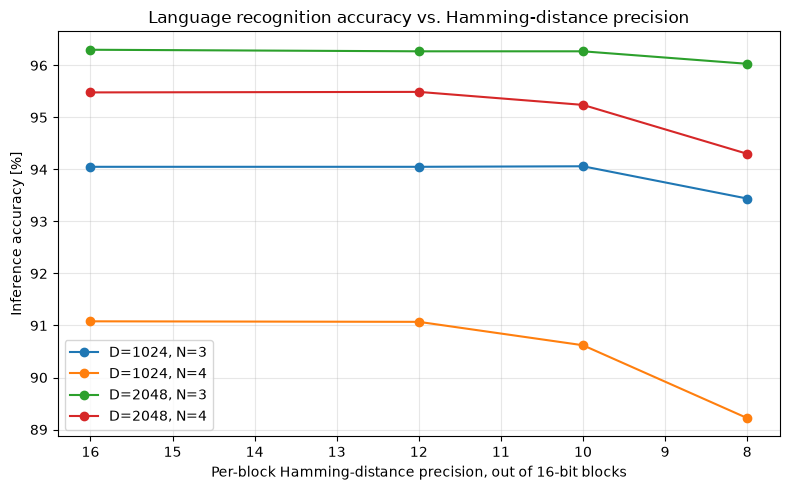

In [5]:
accuracy_by_scenario = {(dimension, n_gram_size): {} for dimension, n_gram_size in dn_scenarios}
for precision, dimension, n_gram_size, accuracy in results:
    accuracy_by_scenario[(dimension, n_gram_size)][precision] = accuracy

plt.figure(figsize=(8, 5))
for dimension, n_gram_size in dn_scenarios:
    xs = sorted(accuracy_by_scenario[(dimension, n_gram_size)], reverse=True)
    ys = [accuracy_by_scenario[(dimension, n_gram_size)][x] * 100 for x in xs]
    plt.plot(xs, ys, marker='o', label=f"D={dimension}, N={n_gram_size}")

plt.gca().invert_xaxis()
plt.xlabel("Per-block Hamming-distance precision, out of 16-bit blocks")
plt.ylabel("Inference accuracy [%]")
plt.title("Language recognition accuracy vs. Hamming-distance precision")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_vs_hamming_precision.png", dpi=150)
plt.show()